In [1]:
import pandas as pd
import plotnine as p9
import numpy as np

In [2]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [4]:
df_comp=pd.read_csv(data_dir+'Gene_UMI_comparison_ChromiumOAKscifi.csv',header=0)

In [5]:
df_comp

,cell_bc,Read_count,n_genes_by_counts,total_counts,call,exp_group
0,B14-TACGGATAGAAGGGCG,114878.0,1408,3714.0,GRCh38,scifi-RNA-seq
1,D20-AACGGGAAGGGTTCTT,116404.0,1339,3610.0,GRCh38,scifi-RNA-seq
2,D14-CTTGTCGAGAGTGGTC,109969.0,1317,3406.0,GRCh38,scifi-RNA-seq
3,P23-GCGTTGGCACTCGGAC,98085.0,1209,3164.0,GRCh38,scifi-RNA-seq
4,A24-ACATGGTCAGTCAGAG,122211.0,1252,3092.0,GRCh38,scifi-RNA-seq
...,...,...,...,...,...,...
59544,TTTGTTGGTGGTCTCG,9260.0,1036,1555.0,mm10,OAK_450kMar
59545,TTTGTTGGTGTATTGC,13360.0,1283,2030.0,GRCh38,OAK_450kMar
59546,TTTGTTGGTTAAGAAC,24593.0,2201,3679.0,GRCh38,OAK_450kMar
59547,TTTGTTGTCCTTTGAT,22758.0,2122,3246.0,GRCh38,OAK_450kMar


In [6]:
df_comp['saturation']=1 - (df_comp['total_counts'] / df_comp['Read_count'])

In [7]:
df_comp

,cell_bc,Read_count,n_genes_by_counts,total_counts,call,exp_group,saturation
0,B14-TACGGATAGAAGGGCG,114878.0,1408,3714.0,GRCh38,scifi-RNA-seq,0.967670
1,D20-AACGGGAAGGGTTCTT,116404.0,1339,3610.0,GRCh38,scifi-RNA-seq,0.968987
2,D14-CTTGTCGAGAGTGGTC,109969.0,1317,3406.0,GRCh38,scifi-RNA-seq,0.969028
3,P23-GCGTTGGCACTCGGAC,98085.0,1209,3164.0,GRCh38,scifi-RNA-seq,0.967742
4,A24-ACATGGTCAGTCAGAG,122211.0,1252,3092.0,GRCh38,scifi-RNA-seq,0.974699
...,...,...,...,...,...,...,...
59544,TTTGTTGGTGGTCTCG,9260.0,1036,1555.0,mm10,OAK_450kMar,0.832073
59545,TTTGTTGGTGTATTGC,13360.0,1283,2030.0,GRCh38,OAK_450kMar,0.848054
59546,TTTGTTGGTTAAGAAC,24593.0,2201,3679.0,GRCh38,OAK_450kMar,0.850405
59547,TTTGTTGTCCTTTGAT,22758.0,2122,3246.0,GRCh38,OAK_450kMar,0.857369


In [11]:
df_comp.exp_group.value_counts()

scifi-RNA-seq    36218
control_10x      10417
OAK_150kMar       7322
OAK_450kMar       5592
Name: exp_group, dtype: int64

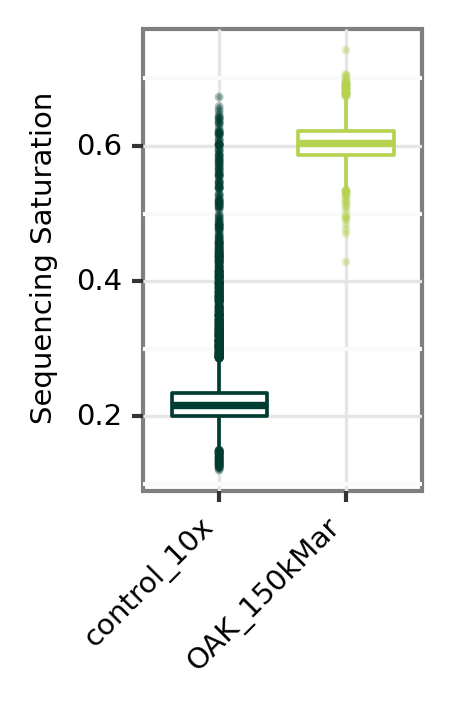

<ggplot: (2932098913979)>

In [13]:
plot=p9.ggplot(data=df_comp[df_comp.exp_group.isin(['control_10x','OAK_150kMar'])],
               mapping=p9.aes(x='exp_group',y='saturation',color='exp_group')
              )
plotsave=plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2,show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.scale_x_discrete(limits=['control_10x','OAK_150kMar']) \
+ p9.scale_color_manual(values = {'control_10x':'#003C30','OAK_150kMar':'#B5D251'}) \
+ p9.theme(axis_text_x=p9.element_text(size=7, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=7, colour="black")) \
+ p9.xlab('') \
+ p9.ylab('Sequencing Saturation') \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.theme(figure_size=(1.2,2)) # inch
plotsave

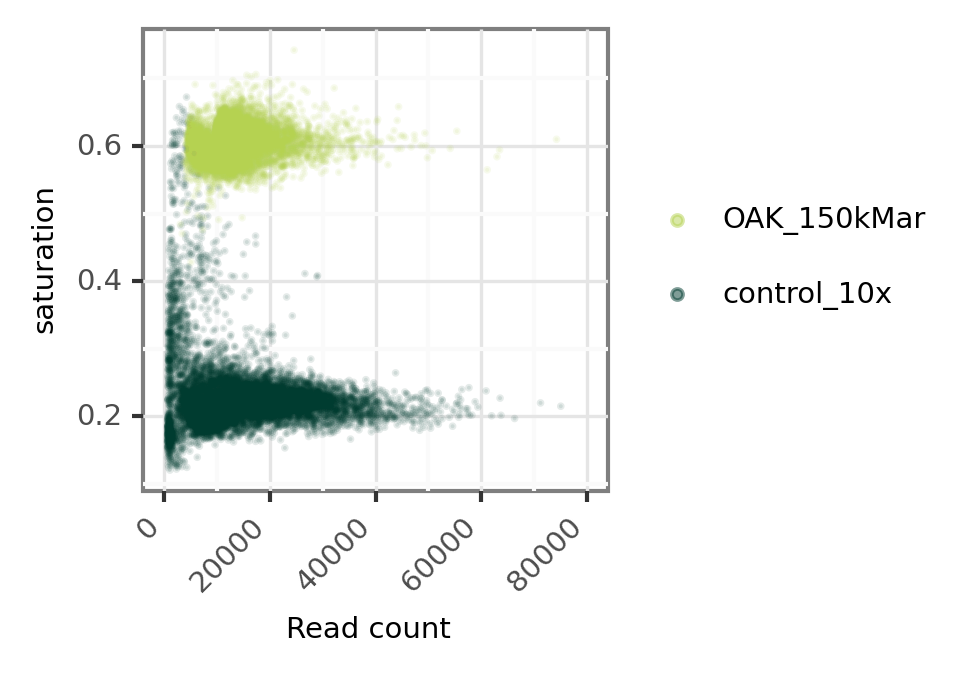

<ggplot: (2932098906844)>

In [14]:
plot=p9.ggplot(data=df_comp[df_comp.exp_group.isin(['control_10x','OAK_150kMar'])],
               mapping=p9.aes(x='Read_count',y='saturation',color='exp_group')
              )
plot+ p9.geom_point(alpha=0.1,size=0.03,show_legend=True) \
+ p9.themes.theme_bw() \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.scale_color_manual(values = {'control_10x':'#003C30','OAK_150kMar':'#B5D251'}) \
+ p9.theme(text=p9.element_text(size=7),legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :1,'alpha':0.5 })) \
+ p9.labels.ylab('saturation') \
+ p9.labels.xlab('Read count') \
+ p9.xlim(0,80000) \
+ p9.theme(figure_size=(2,2)) 

In [15]:
df_comp.groupby('exp_group')['saturation'].mean()

exp_group
OAK_150kMar      0.604421
OAK_450kMar      0.852150
control_10x      0.227253
scifi-RNA-seq    0.946625
Name: saturation, dtype: float64

In [17]:
df_comp.groupby('exp_group')['total_counts'].mean()

exp_group
OAK_150kMar       5255.495903
OAK_450kMar       1921.786302
control_10x      11545.700106
scifi-RNA-seq      240.519770
Name: total_counts, dtype: float64

In [18]:
df_comp[(df_comp.exp_group=='scifi-RNA-seq') & (df_comp.Read_count>13000) & (df_comp.Read_count<17000)]['saturation'].median()

0.9714631034714295

In [19]:
df_comp[(df_comp.exp_group=='scifi-RNA-seq') & (df_comp.Read_count>13000) & (df_comp.Read_count<17000)]['Read_count'].median()

14758.0

In [20]:
df_comp[(df_comp.exp_group=='scifi-RNA-seq') & (df_comp.Read_count>13000) & (df_comp.Read_count<17000)]['total_counts'].median()

425.0